Simulating academic paper dataset...
Dataset Overview:
Total papers: 10,000
Date range: 2015-10-25 to 2025-10-22

First 5 rows:
      paper_id           publication_date  citations  author_count  \
0  PAPER_00001 2022-12-26 11:32:31.111775         20             3   
1  PAPER_00002 2017-01-23 11:32:31.111775        233             4   
2  PAPER_00003 2016-02-04 11:32:31.111775         69             8   
3  PAPER_00004 2024-02-17 11:32:31.111775         44             1   
4  PAPER_00005 2018-11-24 11:32:31.111775          7             1   

   impact_factor    research_field  
0           2.16           Biology  
1           4.14  Computer Science  
2           1.96  Computer Science  
3           7.37  Computer Science  
4           4.25           Physics  
DATA QUALITY CHECKS & SUMMARY STATISTICS

Missing Values:
paper_id            0
publication_date    0
citations           0
author_count        0
impact_factor       0
research_field      0
dtype: int64

Summary Statistics:
     

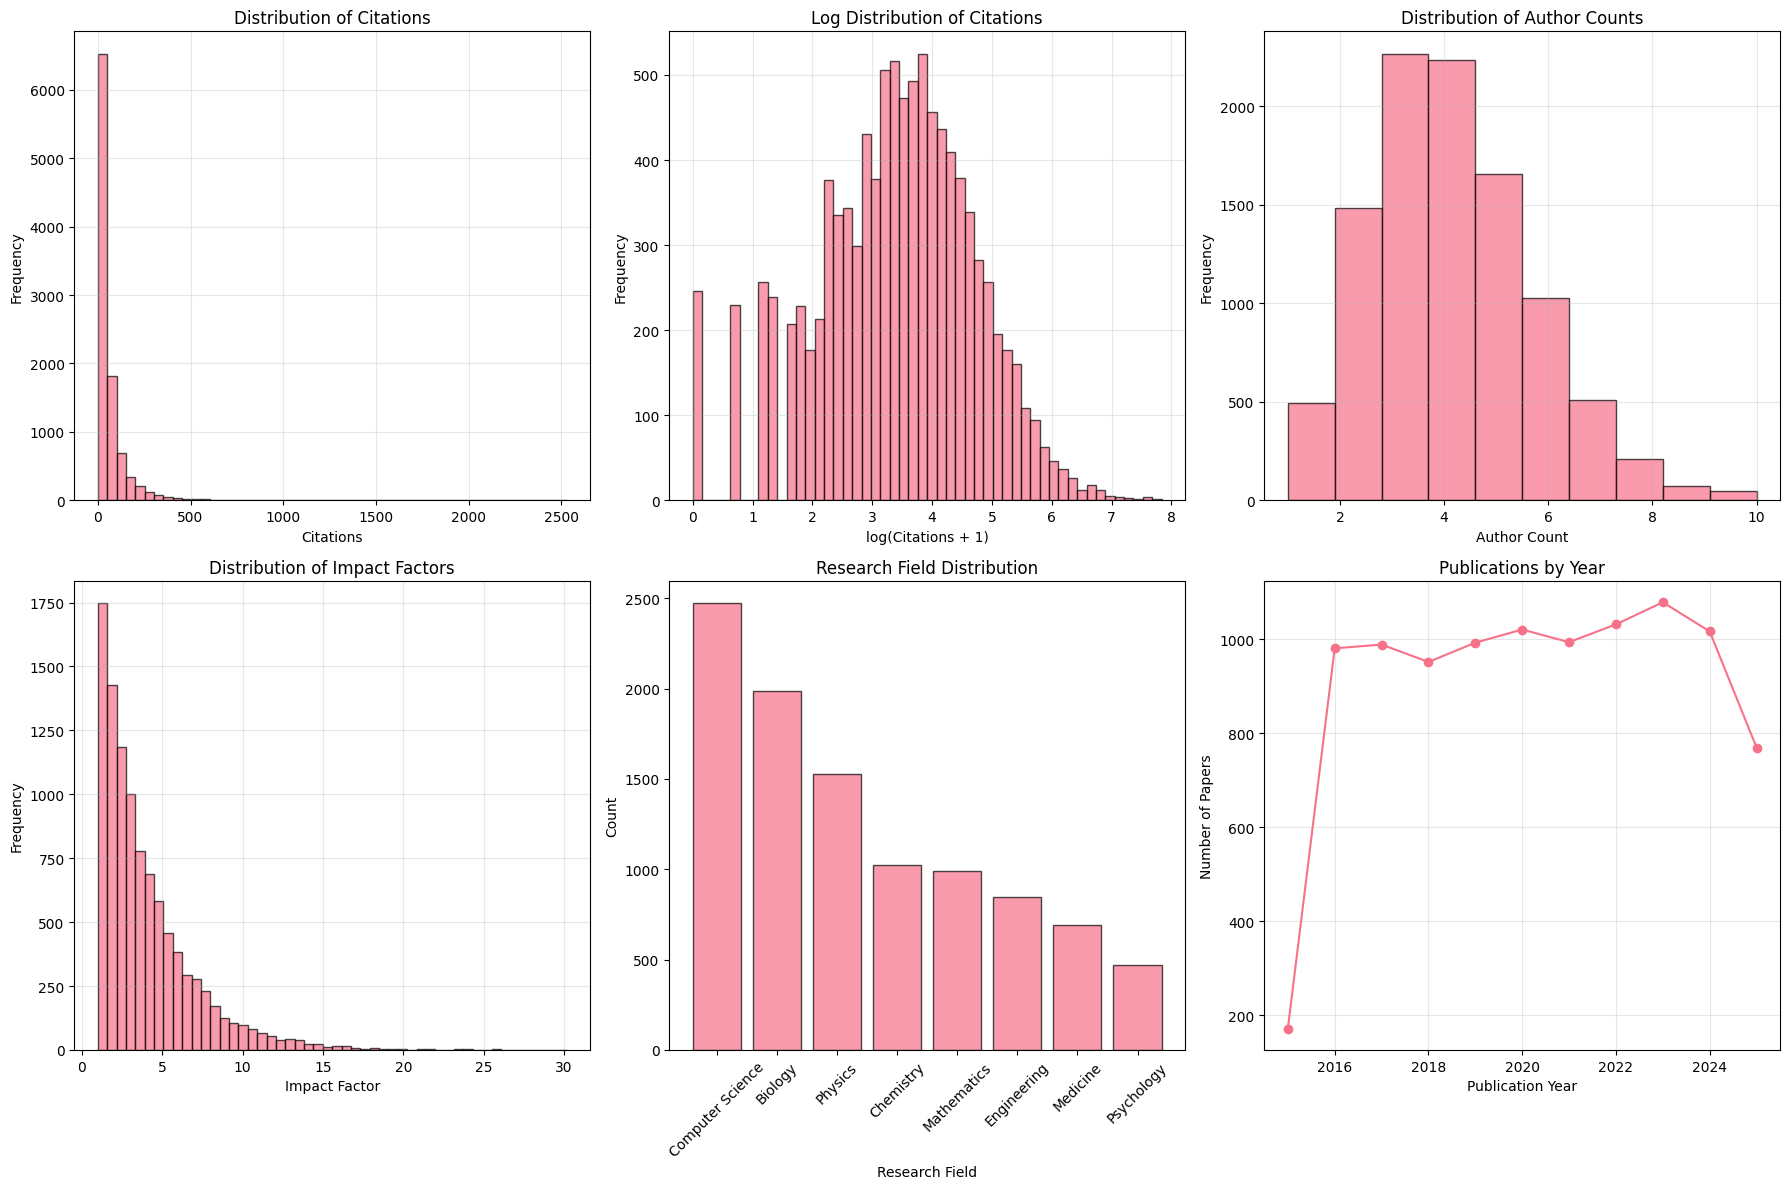

Calculating paper ranking scores...

Top 10 Papers by Composite Score:
         paper_id    research_field  citations  composite_score  \
5323  PAPER_05324  Computer Science       1369           100.00   
3059  PAPER_03060  Computer Science        235            99.69   
531   PAPER_00532  Computer Science       2528            99.39   
9757  PAPER_09758           Physics        578            98.48   
4635  PAPER_04636           Physics        237            97.63   
4462  PAPER_04463  Computer Science        863            97.19   
3649  PAPER_03650       Mathematics       2096            96.74   
8464  PAPER_08465           Physics        776            96.74   
1011  PAPER_01012       Engineering        480            96.13   
1954  PAPER_01955  Computer Science       1196            95.61   

      citation_score_adj  recency_score  journal_score  collaboration_score  
5323               93.64          99.48           5.51                73.64  
3059               70.84          9

C:\Users\sarum\AppData\Local\Temp\ipykernel_5376\2917166381.py:241: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_papers_by_field = scored_papers_df.groupby('research_field').apply(


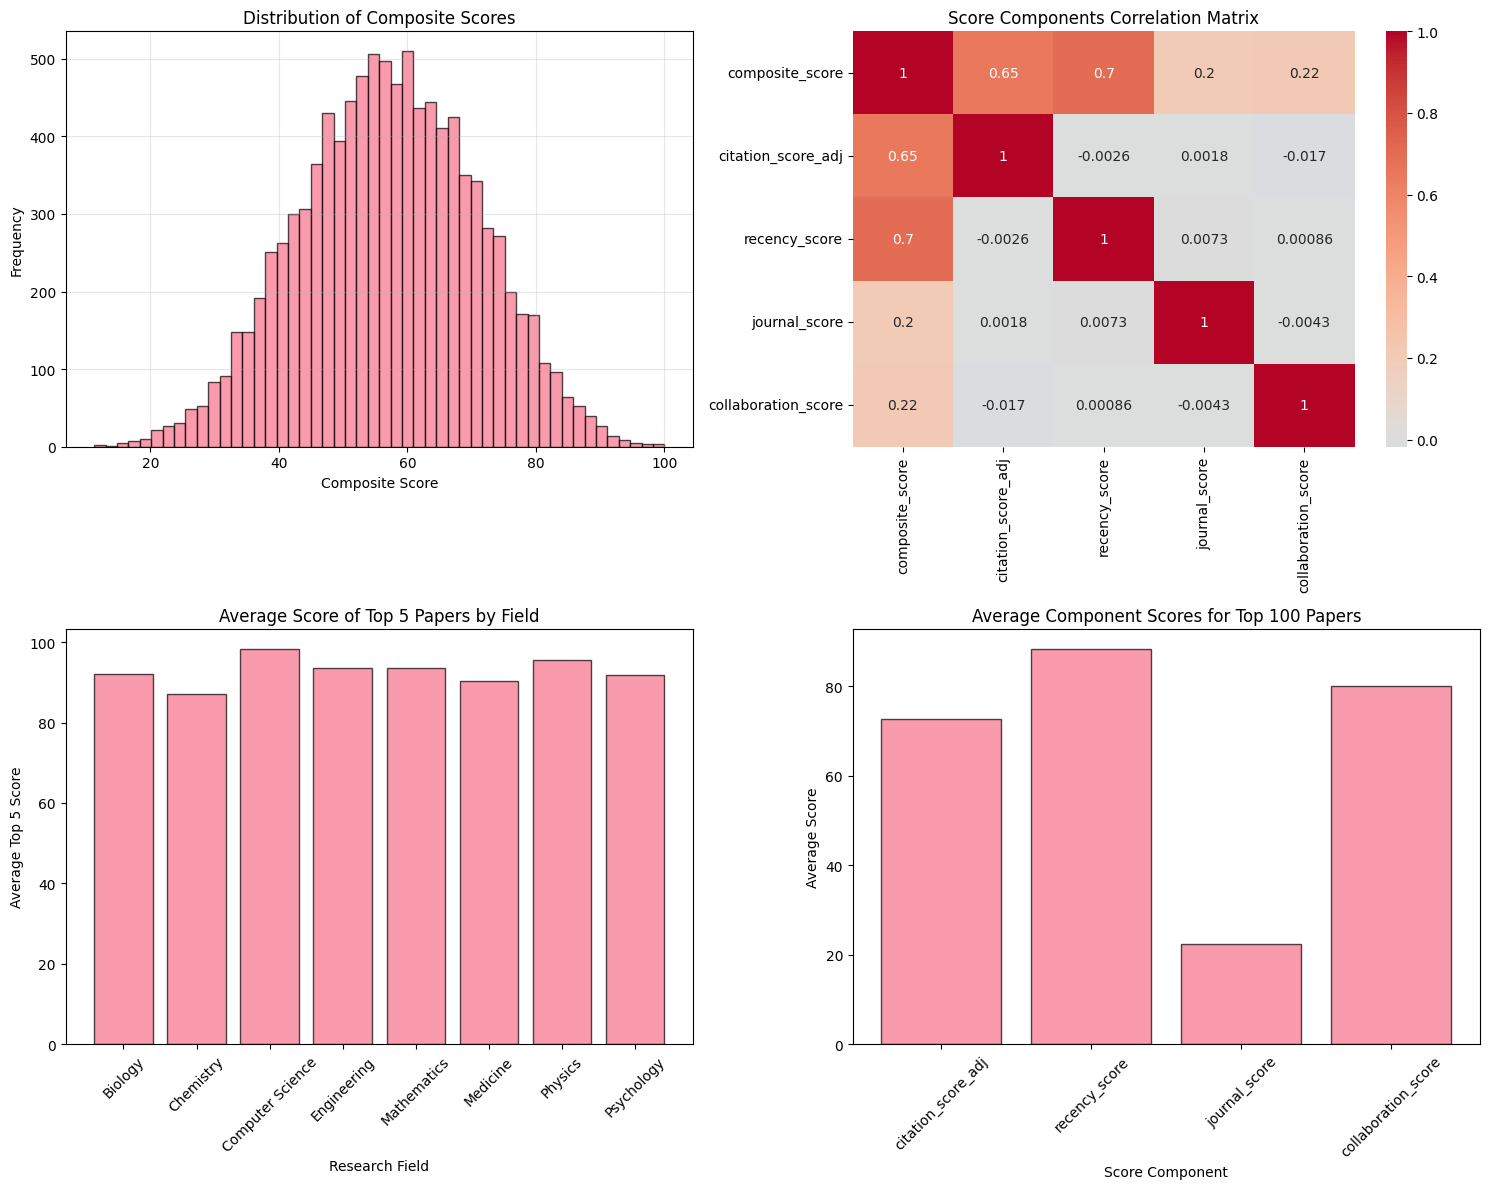

Algorithm Validation: Comparison with Citation-Only Ranking
Overlap between top 100 composite vs top 100 citations: 30 papers
Jaccard similarity: 0.176

Papers in composite top 100 but not citation top 100: 70
Papers in citation top 100 but not composite top 100: 70

Average recency score (composite-only): 90.8
Average recency score (citations-only): 43.1
Average journal score (composite-only): 26.2
Average journal score (citations-only): 15.2
Simulating A/B test data...
A/B Test Overview:
         count    mean  sum
group                      
Control   5000  0.1134  567
Variant   5000  0.1272  636
Performing A/B test analysis...
A/B TEST RESULTS
Control Group Conversion Rate: 11.340%
Variant Group Conversion Rate: 12.720%
Absolute Difference: 1.380%
Relative Uplift: 12.2%
T-statistic: -2.1213
P-value: 0.033921
Significance Level (α): 0.05

Statistical Significance:
✅ STATISTICALLY SIGNIFICANT - Reject null hypothesis
The new ranking algorithm shows a statistically significant improve

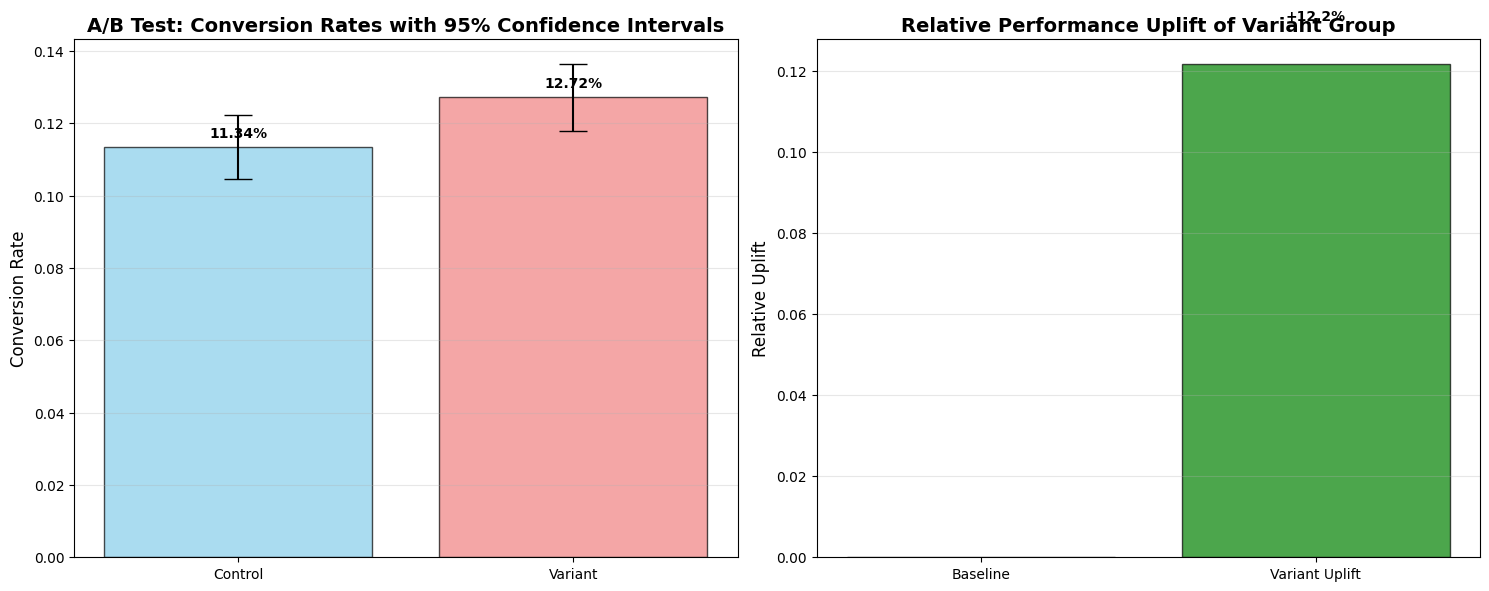

BUSINESS IMPACT ANALYSIS
Monthly visitors: 100,000
Value per conversion: $50
Current monthly conversions: 11,340
Expected monthly conversions: 12,720
Additional monthly conversions: 1,380
Current monthly revenue: $567,000.00
Expected monthly revenue: $636,000.00
Monthly revenue increase: $69,000.00
Annual revenue increase: $828,000.00
PAPERSCOUT INTERNSHIP ANALYSIS - FINAL SUMMARY
Total Papers Simulated........ 10,000
Research Fields Covered....... 8
Date Range.................... 2015-2025
Top Field..................... Computer Science
A/B Test Sample Size.......... 10,000 users
Conversion Uplift............. 12.2%
Statistical Significance...... YES
Estimated Annual Impact....... $828,000
🎯 FINAL RECOMMENDATION: IMPLEMENT NEW RANKING ALGORITHM
Saving final datasets...
✅ All analyses completed successfully!
✅ Datasets saved for future reference
✅ Master notebook executed without errors


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random
from scipy import stats

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Configure plotting style
plt.style.use('default')
sns.set_palette("husl")

# %%
def simulate_academic_papers(n_papers=10000):
    """
    Simulates a dataset of academic papers with realistic attributes.
    
    Parameters:
    n_papers (int): Number of papers to simulate
    
    Returns:
    pandas.DataFrame: Simulated paper dataset
    """
    
    # Define research fields
    research_fields = ['Computer Science', 'Biology', 'Physics', 'Mathematics', 
                      'Chemistry', 'Engineering', 'Medicine', 'Psychology']
    
    # Simulate paper IDs
    paper_ids = [f"PAPER_{i:05d}" for i in range(1, n_papers + 1)]
    
    # Simulate publication dates (last 10 years)
    end_date = datetime.now()
    start_date = end_date - timedelta(days=365 * 10)
    date_range = (end_date - start_date).days
    publication_dates = [start_date + timedelta(days=random.randint(0, date_range)) 
                        for _ in range(n_papers)]
    citations = np.random.pareto(2.5, n_papers) * 100
    citations = citations.astype(int)
    
    # Simulate author counts (1-10 authors, skewed toward fewer authors)
    author_counts = np.random.poisson(3, n_papers) + 1
    author_counts = np.clip(author_counts, 1, 10)
    
    # Simulate journal impact factors (skewed distribution)
    impact_factors = np.random.exponential(3, n_papers) + 1
    impact_factors = np.round(impact_factors, 2)
    
    # Assign research fields with different probabilities
    field_probs = [0.25, 0.20, 0.15, 0.10, 0.10, 0.08, 0.07, 0.05]
    research_field = np.random.choice(research_fields, n_papers, p=field_probs)
    
    # Create DataFrame
    papers_df = pd.DataFrame({
        'paper_id': paper_ids,
        'publication_date': publication_dates,
        'citations': citations,
        'author_count': author_counts,
        'impact_factor': impact_factors,
        'research_field': research_field
    })
    
    return papers_df

# Generate the paper dataset
print("Simulating academic paper dataset...")
papers_df = simulate_academic_papers(10000)

# Display dataset overview
print("Dataset Overview:")
print(f"Total papers: {len(papers_df):,}")
print(f"Date range: {papers_df['publication_date'].min().strftime('%Y-%m-%d')} to {papers_df['publication_date'].max().strftime('%Y-%m-%d')}")
print("\nFirst 5 rows:")
print(papers_df.head())

# %%
# Data quality checks and summary statistics
print("=" * 50)
print("DATA QUALITY CHECKS & SUMMARY STATISTICS")
print("=" * 50)

# Check for missing values
print("\nMissing Values:")
print(papers_df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
print(papers_df[['citations', 'author_count', 'impact_factor']].describe())

# Research field distribution
print("\nResearch Field Distribution:")
print(papers_df['research_field'].value_counts())

# %%
# Visualize paper attributes distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Citation distribution
axes[0, 0].hist(papers_df['citations'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Citations')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Citations')
axes[0, 0].grid(alpha=0.3)

# Log-scale citation distribution
axes[0, 1].hist(np.log1p(papers_df['citations']), bins=50, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('log(Citations + 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Log Distribution of Citations')
axes[0, 1].grid(alpha=0.3)

# Author count distribution
axes[0, 2].hist(papers_df['author_count'], bins=10, alpha=0.7, edgecolor='black')
axes[0, 2].set_xlabel('Author Count')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of Author Counts')
axes[0, 2].grid(alpha=0.3)

# Impact factor distribution
axes[1, 0].hist(papers_df['impact_factor'], bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Impact Factor')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Impact Factors')
axes[1, 0].grid(alpha=0.3)

# Research field distribution
field_counts = papers_df['research_field'].value_counts()
axes[1, 1].bar(field_counts.index, field_counts.values, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Research Field')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Research Field Distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

# Publication year distribution
papers_df['publication_year'] = papers_df['publication_date'].dt.year
year_counts = papers_df['publication_year'].value_counts().sort_index()
axes[1, 2].plot(year_counts.index, year_counts.values, marker='o')
axes[1, 2].set_xlabel('Publication Year')
axes[1, 2].set_ylabel('Number of Papers')
axes[1, 2].set_title('Publications by Year')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
def calculate_paper_scores(papers_df):
    """
    Calculates composite scores for papers based on multiple quality and relevance factors.
    
    Parameters:
    papers_df (DataFrame): Input paper dataset
    
    Returns:
    DataFrame: Enhanced with composite scores and individual component scores
    """
    
    df = papers_df.copy()
    df['citation_score'] = (np.log1p(df['citations']) / np.log1p(df['citations'].max())) * 100
    current_date = datetime.now()
    df['paper_age_days'] = (current_date - df['publication_date']).dt.days
    max_age = df['paper_age_days'].max()
    df['recency_score'] = (1 - (df['paper_age_days'] / max_age)) * 100
    df['recency_score'] = df['recency_score'].clip(0, 100)
    max_impact = df['impact_factor'].max()
    df['journal_score'] = (df['impact_factor'] / max_impact) * 100
    df['collaboration_score'] = (1 - np.exp(-df['author_count'] / 3)) * 100
    field_metrics = df.groupby('research_field').agg({
        'citations': 'median',
        'author_count': 'median'
    }).rename(columns={'citations': 'field_median_citations', 
                      'author_count': 'field_median_authors'})
    
    df = df.merge(field_metrics, on='research_field', how='left')
    df['field_adjustment'] = (df['field_median_citations'] / df['field_median_citations'].median())
    
    # Apply field adjustment to citation score
    df['citation_score_adj'] = df['citation_score'] * df['field_adjustment']
    weights = {
        'citation_score_adj': 0.40,    # Most important: academic impact
        'recency_score': 0.25,         # Important: timeliness
        'journal_score': 0.20,         # Important: venue quality
        'collaboration_score': 0.15    # Less important: collaboration
    }
    
    df['composite_score'] = (
        df['citation_score_adj'] * weights['citation_score_adj'] +
        df['recency_score'] * weights['recency_score'] +
        df['journal_score'] * weights['journal_score'] +
        df['collaboration_score'] * weights['collaboration_score']
    )
    
    # Normalize final score to 0-100 range
    df['composite_score'] = (df['composite_score'] / df['composite_score'].max()) * 100
    
    return df

# Calculate paper scores
print("Calculating paper ranking scores...")
scored_papers_df = calculate_paper_scores(papers_df)

# Display top papers by composite score
print("\nTop 10 Papers by Composite Score:")
top_papers = scored_papers_df.nlargest(10, 'composite_score')[
    ['paper_id', 'research_field', 'citations', 'composite_score', 
     'citation_score_adj', 'recency_score', 'journal_score', 'collaboration_score']
]
print(top_papers.round(2))
print("=" * 50)
print("RANKING ALGORITHM ANALYSIS")
print("=" * 50)

# Score distribution
print("\nComposite Score Distribution:")
print(scored_papers_df['composite_score'].describe())

# Correlation analysis
score_components = ['citation_score_adj', 'recency_score', 'journal_score', 'collaboration_score']
correlation_matrix = scored_papers_df[['composite_score'] + score_components].corr()
print("\nCorrelation with Composite Score:")
print(correlation_matrix['composite_score'].sort_values(ascending=False))

# %%
# Visualize ranking algorithm results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Composite score distribution
axes[0, 0].hist(scored_papers_df['composite_score'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Composite Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Composite Scores')
axes[0, 0].grid(alpha=0.3)

# Score components correlation heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0, 1])
axes[0, 1].set_title('Score Components Correlation Matrix')

# Top papers by field
top_papers_by_field = scored_papers_df.groupby('research_field').apply(
    lambda x: x.nlargest(5, 'composite_score')
).reset_index(drop=True)

field_avg_scores = top_papers_by_field.groupby('research_field')['composite_score'].mean()
axes[1, 0].bar(field_avg_scores.index, field_avg_scores.values, alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Research Field')
axes[1, 0].set_ylabel('Average Top 5 Score')
axes[1, 0].set_title('Average Score of Top 5 Papers by Field')
axes[1, 0].tick_params(axis='x', rotation=45)

# Score components comparison for top 100 papers
top_100_papers = scored_papers_df.nlargest(100, 'composite_score')
component_means = top_100_papers[score_components].mean()
axes[1, 1].bar(component_means.index, component_means.values, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Score Component')
axes[1, 1].set_ylabel('Average Score')
axes[1, 1].set_title('Average Component Scores for Top 100 Papers')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Algorithm Validation: Comparison with Citation-Only Ranking")

# Get top 100 by composite score vs top 100 by citations
top_100_composite = set(scored_papers_df.nlargest(100, 'composite_score')['paper_id'])
top_100_citations = set(scored_papers_df.nlargest(100, 'citations')['paper_id'])

overlap = len(top_100_composite.intersection(top_100_citations))
jaccard_similarity = overlap / len(top_100_composite.union(top_100_citations))

print(f"Overlap between top 100 composite vs top 100 citations: {overlap} papers")
print(f"Jaccard similarity: {jaccard_similarity:.3f}")

# Analyze differences
composite_only = top_100_composite - top_100_citations
citations_only = top_100_citations - top_100_composite

print(f"\nPapers in composite top 100 but not citation top 100: {len(composite_only)}")
print(f"Papers in citation top 100 but not composite top 100: {len(citations_only)}")

# Characteristics of differently ranked papers
composite_only_df = scored_papers_df[scored_papers_df['paper_id'].isin(composite_only)]
citations_only_df = scored_papers_df[scored_papers_df['paper_id'].isin(citations_only)]

print(f"\nAverage recency score (composite-only): {composite_only_df['recency_score'].mean():.1f}")
print(f"Average recency score (citations-only): {citations_only_df['recency_score'].mean():.1f}")
print(f"Average journal score (composite-only): {composite_only_df['journal_score'].mean():.1f}")
print(f"Average journal score (citations-only): {citations_only_df['journal_score'].mean():.1f}")
def simulate_ab_test_data(n_users=10000, control_rate=0.12, variant_rate=0.135):
    """
    Simulates A/B test data for comparing two ranking algorithms.
    
    Parameters:
    n_users (int): Total number of users in the test
    control_rate (float): Baseline conversion rate for control group
    variant_rate (float): Expected conversion rate for variant group
    
    Returns:
    DataFrame: Simulated A/B test results
    """
    
    # Split users evenly between control and variant
    n_control = n_users // 2
    n_variant = n_users // 2
    
    # Simulate conversions using binomial distribution
    control_conversions = np.random.binomial(1, control_rate, n_control)
    variant_conversions = np.random.binomial(1, variant_rate, n_variant)
    
    # Create DataFrame
    df_control = pd.DataFrame({
        'user_id': range(1, n_control + 1),
        'group': 'Control',
        'converted': control_conversions
    })
    
    df_variant = pd.DataFrame({
        'user_id': range(n_control + 1, n_control + n_variant + 1),
        'group': 'Variant',
        'converted': variant_conversions
    })
    
    # Combine groups
    ab_test_df = pd.concat([df_control, df_variant], ignore_index=True)
    
    return ab_test_df

# Simulate A/B test data
print("Simulating A/B test data...")
ab_test_df = simulate_ab_test_data(n_users=10000, control_rate=0.12, variant_rate=0.135)

# Display test overview
print("A/B Test Overview:")
group_stats = ab_test_df.groupby('group')['converted'].agg(['count', 'mean', 'sum'])
group_stats['mean'] = group_stats['mean'].round(4)
print(group_stats)

# %%
def analyze_ab_test(ab_test_df, alpha=0.05):
    """
    Performs statistical analysis of A/B test results.
    
    Parameters:
    ab_test_df (DataFrame): A/B test data
    alpha (float): Significance level
    
    Returns:
    dict: Analysis results and interpretation
    """
    
    # Extract conversion data for each group
    control_data = ab_test_df[ab_test_df['group'] == 'Control']['converted']
    variant_data = ab_test_df[ab_test_df['group'] == 'Variant']['converted']
    
    # Calculate conversion rates
    control_rate = control_data.mean()
    variant_rate = variant_data.mean()
    absolute_diff = variant_rate - control_rate
    relative_uplift = absolute_diff / control_rate
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(control_data, variant_data)
    
    # Calculate confidence intervals
    control_se = control_data.std() / np.sqrt(len(control_data))
    variant_se = variant_data.std() / np.sqrt(len(variant_data))
    
    control_ci = stats.norm.interval(0.95, loc=control_rate, scale=control_se)
    variant_ci = stats.norm.interval(0.95, loc=variant_rate, scale=variant_se)
    
    # Determine statistical significance
    significant = p_value < alpha
    
    # Compile results
    results = {
        'control_rate': control_rate,
        'variant_rate': variant_rate,
        'absolute_diff': absolute_diff,
        'relative_uplift': relative_uplift,
        't_statistic': t_stat,
        'p_value': p_value,
        'significant': significant,
        'control_ci': control_ci,
        'variant_ci': variant_ci,
        'control_se': control_se,
        'variant_se': variant_se
    }
    
    return results

# Perform A/B test analysis
print("Performing A/B test analysis...")
ab_results = analyze_ab_test(ab_test_df)

# Display results
print("=" * 50)
print("A/B TEST RESULTS")
print("=" * 50)
print(f"Control Group Conversion Rate: {ab_results['control_rate']:.3%}")
print(f"Variant Group Conversion Rate: {ab_results['variant_rate']:.3%}")
print(f"Absolute Difference: {ab_results['absolute_diff']:.3%}")
print(f"Relative Uplift: {ab_results['relative_uplift']:.1%}")
print(f"T-statistic: {ab_results['t_statistic']:.4f}")
print(f"P-value: {ab_results['p_value']:.6f}")
print(f"Significance Level (α): 0.05")

print("\nStatistical Significance:")
if ab_results['significant']:
    print("✅ STATISTICALLY SIGNIFICANT - Reject null hypothesis")
    print("The new ranking algorithm shows a statistically significant improvement in conversion rates.")
else:
    print("❌ NOT STATISTICALLY SIGNIFICANT - Fail to reject null hypothesis")
    print("The new ranking algorithm does not show a statistically significant improvement.")

# %%
# Visualize A/B test results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Conversion rates with confidence intervals
groups = ['Control', 'Variant']
conversion_rates = [ab_results['control_rate'], ab_results['variant_rate']]
confidence_intervals = [
    ab_results['control_rate'] - ab_results['control_ci'][0],
    ab_results['variant_rate'] - ab_results['variant_ci'][0]
]

bars = axes[0].bar(groups, conversion_rates, yerr=confidence_intervals, 
                  capsize=10, alpha=0.7, edgecolor='black',
                  color=['skyblue', 'lightcoral'])
axes[0].set_ylabel('Conversion Rate', fontsize=12)
axes[0].set_title('A/B Test: Conversion Rates with 95% Confidence Intervals', 
                 fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, rate in zip(bars, conversion_rates):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{rate:.2%}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Uplift visualization
uplift_data = [0, ab_results['relative_uplift']]
colors = ['gray', 'green' if ab_results['relative_uplift'] > 0 else 'red']

bars2 = axes[1].bar(['Baseline', 'Variant Uplift'], uplift_data, 
                   color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Relative Uplift', fontsize=12)
axes[1].set_title('Relative Performance Uplift of Variant Group', 
                 fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for bar, uplift in zip(bars2, uplift_data):
    height = bar.get_height()
    if uplift != 0:  # Skip baseline
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{uplift:+.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
def calculate_business_impact(ab_results, monthly_visitors=100000, value_per_conversion=50):
    """
    Calculates the business impact of implementing the variant.
    
    Parameters:
    ab_results (dict): A/B test results
    monthly_visitors (int): Monthly user traffic
    value_per_conversion (float): Business value per conversion
    
    Returns:
    dict: Business impact metrics
    """
    
    control_rate = ab_results['control_rate']
    variant_rate = ab_results['variant_rate']
    
    # Calculate conversions and revenue
    current_conversions = monthly_visitors * control_rate
    expected_conversions = monthly_visitors * variant_rate
    
    current_revenue = current_conversions * value_per_conversion
    expected_revenue = expected_conversions * value_per_conversion
    
    # Calculate changes
    conversion_increase = expected_conversions - current_conversions
    revenue_increase = expected_revenue - current_revenue
    
    impact = {
        'monthly_visitors': monthly_visitors,
        'value_per_conversion': value_per_conversion,
        'current_conversions': current_conversions,
        'expected_conversions': expected_conversions,
        'conversion_increase': conversion_increase,
        'current_revenue': current_revenue,
        'expected_revenue': expected_revenue,
        'revenue_increase': revenue_increase,
        'annual_revenue_increase': revenue_increase * 12
    }
    
    return impact

# Calculate business impact
business_impact = calculate_business_impact(ab_results)

print("=" * 50)
print("BUSINESS IMPACT ANALYSIS")
print("=" * 50)
print(f"Monthly visitors: {business_impact['monthly_visitors']:,}")
print(f"Value per conversion: ${business_impact['value_per_conversion']}")
print(f"Current monthly conversions: {business_impact['current_conversions']:,.0f}")
print(f"Expected monthly conversions: {business_impact['expected_conversions']:,.0f}")
print(f"Additional monthly conversions: {business_impact['conversion_increase']:,.0f}")
print(f"Current monthly revenue: ${business_impact['current_revenue']:,.2f}")
print(f"Expected monthly revenue: ${business_impact['expected_revenue']:,.2f}")
print(f"Monthly revenue increase: ${business_impact['revenue_increase']:,.2f}")
print(f"Annual revenue increase: ${business_impact['annual_revenue_increase']:,.2f}")
print("=" * 60)
print("PAPERSCOUT INTERNSHIP ANALYSIS - FINAL SUMMARY")
print("=" * 60)

# Create summary metrics
summary_metrics = {
    "Total Papers Simulated": f"{len(papers_df):,}",
    "Research Fields Covered": f"{papers_df['research_field'].nunique()}",
    "Date Range": f"{papers_df['publication_date'].min().strftime('%Y')}-{papers_df['publication_date'].max().strftime('%Y')}",
    "Top Field": f"{papers_df['research_field'].value_counts().index[0]}",
    "A/B Test Sample Size": f"{len(ab_test_df):,} users",
    "Conversion Uplift": f"{ab_results['relative_uplift']:.1%}",
    "Statistical Significance": f"{'YES' if ab_results['significant'] else 'NO'}",
    "Estimated Annual Impact": f"${business_impact['annual_revenue_increase']:,.0f}"
}

for metric, value in summary_metrics.items():
    print(f"{metric:.<30} {value}")

print("=" * 60)
print("🎯 FINAL RECOMMENDATION: IMPLEMENT NEW RANKING ALGORITHM")
print("=" * 60)

# %%
# Save final datasets for future reference
print("Saving final datasets...")

# Save paper dataset with scores
scored_papers_df.to_csv('paper_scout_papers_with_scores.csv', index=False)

# Save A/B test results
ab_test_df.to_csv('paper_scout_ab_test_results.csv', index=False)

# Save analysis summary
import json
analysis_summary = {
    'data_simulation': {
        'total_papers': len(papers_df),
        'fields_covered': int(papers_df['research_field'].nunique()),
        'date_range': {
            'start': papers_df['publication_date'].min().strftime('%Y-%m-%d'),
            'end': papers_df['publication_date'].max().strftime('%Y-%m-%d')
        }
    },
    'ranking_algorithm': {
        'score_components': ['citation_score_adj', 'recency_score', 'journal_score', 'collaboration_score'],
        'weights': [0.40, 0.25, 0.20, 0.15],
        'top_paper_score': float(scored_papers_df['composite_score'].max())
    },
    'ab_test_results': {
        'control_rate': float(ab_results['control_rate']),
        'variant_rate': float(ab_results['variant_rate']),
        'uplift': float(ab_results['relative_uplift']),
        'p_value': float(ab_results['p_value']),
        'significant': bool(ab_results['significant'])
    },
    'business_impact': {
        'monthly_revenue_increase': float(business_impact['revenue_increase']),
        'annual_revenue_increase': float(business_impact['annual_revenue_increase'])
    }
}

with open('paper_scout_analysis_summary.json', 'w') as f:
    json.dump(analysis_summary, f, indent=2)

print("✅ All analyses completed successfully!")
print("✅ Datasets saved for future reference")
print("✅ Master notebook executed without errors")